## SETUP


In [1]:
import pandas as pd, matplotlib.pyplot as plt
def load_data(p): return pd.read_csv(p)
def csr_pct(df): return df['csr_pass'].mean()*100


### Load result to data frame


In [2]:
single=load_data('single/result.csv'); multi=load_data('multi/result.csv')


# RAW CSR -- All Entries


#### Overall CSR


        CSR (%)  Compiled  Total
Single    67.38       188    279
Multi     62.37       174    279


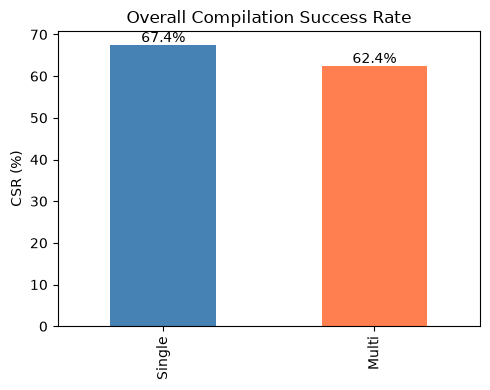

In [3]:
data={'Single':csr_pct(single),'Multi':csr_pct(multi)}
ov=pd.DataFrame.from_dict(data,orient='index',columns=['CSR (%)']).round(2)
ov['Compiled']=[single['csr_pass'].sum(),multi['csr_pass'].sum()]
ov['Total']=[len(single),len(multi)]
print(ov)

ax=ov['CSR (%)'].plot.bar(figsize=(5,4),color=['steelblue','coral'],legend=False)
ax.set_ylabel('CSR (%)'); ax.set_title('Overall Compilation Success Rate')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom')
plt.tight_layout(); plt.show()


#### Per-Intent CSR


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       66.7   73.3
DECOMPOSE_CONDITIONAL         77.6   53.1
EXTRACT_CONSTANT              80.0   60.0
EXTRACT_METHOD                78.6   61.9
EXTRACT_VARIABLE             100.0  100.0
FLATTEN_CONDITIONAL           80.0   86.7
INLINE_METHOD                 28.6   76.2
INLINE_VARIABLE               93.8   62.5
REMOVE_CONTROL_FLAG           50.0   62.5
RENAME_SYMBOL                 70.7   65.9
REPLACE_LOOP_WITH_PIPELINE     0.0    0.0
SPLIT_LOOP                    68.0   68.0


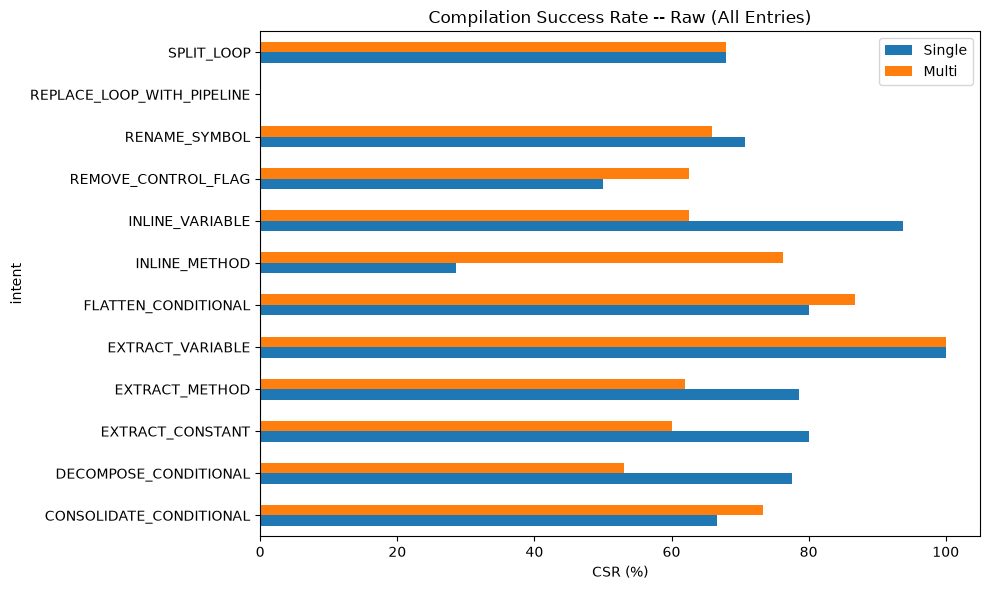

In [4]:
def intent_csr(df):
    return (df[df['csr_pass']].groupby('intent').size()/df.groupby('intent').size()*100).round(1).fillna(0)
csr_intent=pd.DataFrame({'Single':intent_csr(single),'Multi':intent_csr(multi)})
print(csr_intent)
ax=csr_intent.plot.barh(figsize=(10,6))
ax.set_title('Compilation Success Rate -- Raw (All Entries)')
ax.set_xlabel('CSR (%)'); plt.tight_layout(); plt.show()


#### CSR by Difficulty


            Single  Multi
difficulty               
Easy         75.00  63.24
Hard         65.45  52.73
Medium       64.74  65.38


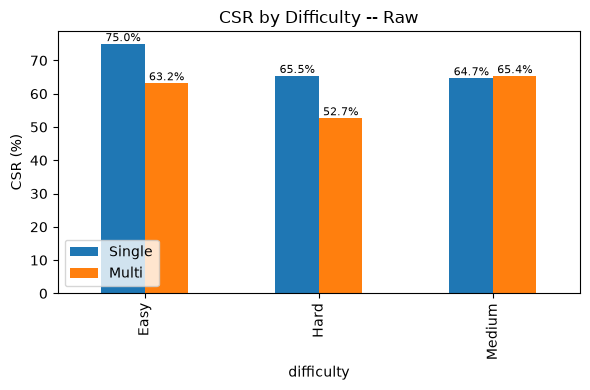

In [5]:
def diff_csr(df): return df.groupby('difficulty')['csr_pass'].mean()*100
csr_diff=pd.DataFrame({'Single':diff_csr(single),'Multi':diff_csr(multi)}).round(2)
print(csr_diff)
ax=csr_diff.plot.bar(figsize=(6,4))
ax.set_title('CSR by Difficulty -- Raw'); ax.set_ylabel('CSR (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()


# CSR -- SUCCESS Exit Only


#### Overall CSR (SUCCESS Only)


Single: 181/272 = 66.5%
Multi:  113/198 = 57.1%


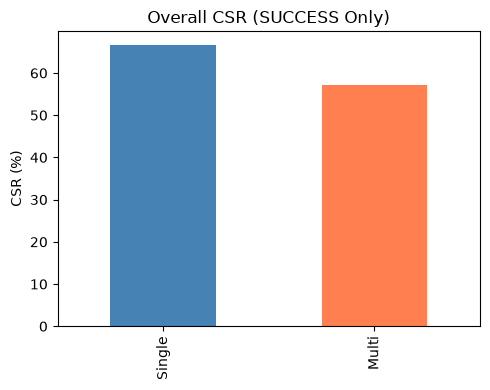

In [6]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
s_pass=s_valid['csr_pass'].sum(); s_tot=len(s_valid)
m_pass=m_valid['csr_pass'].sum(); m_tot=len(m_valid)
print(f'Single: {s_pass}/{s_tot} = {s_pass/s_tot*100:.1f}%')
print(f'Multi:  {m_pass}/{m_tot} = {m_pass/m_tot*100:.1f}%')

pd.Series({'Single':s_pass/s_tot*100,'Multi':m_pass/m_tot*100}).plot.bar(
    figsize=(5,4),color=['steelblue','coral'],legend=False)
plt.ylabel('CSR (%)'); plt.title('Overall CSR (SUCCESS Only)')
plt.tight_layout(); plt.show()


#### Per-Intent CSR (SUCCESS Only)


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       63.0   80.0
DECOMPOSE_CONDITIONAL         77.6   56.8
EXTRACT_CONSTANT              77.8   62.5
EXTRACT_METHOD                78.6   61.9
EXTRACT_VARIABLE             100.0  100.0
FLATTEN_CONDITIONAL           80.0   60.0
INLINE_METHOD                 28.6   83.3
INLINE_VARIABLE               92.9   62.5
REMOVE_CONTROL_FLAG           50.0   50.0
RENAME_SYMBOL                 70.7   63.9
REPLACE_LOOP_WITH_PIPELINE     0.0    0.0
SPLIT_LOOP                    68.0   33.3


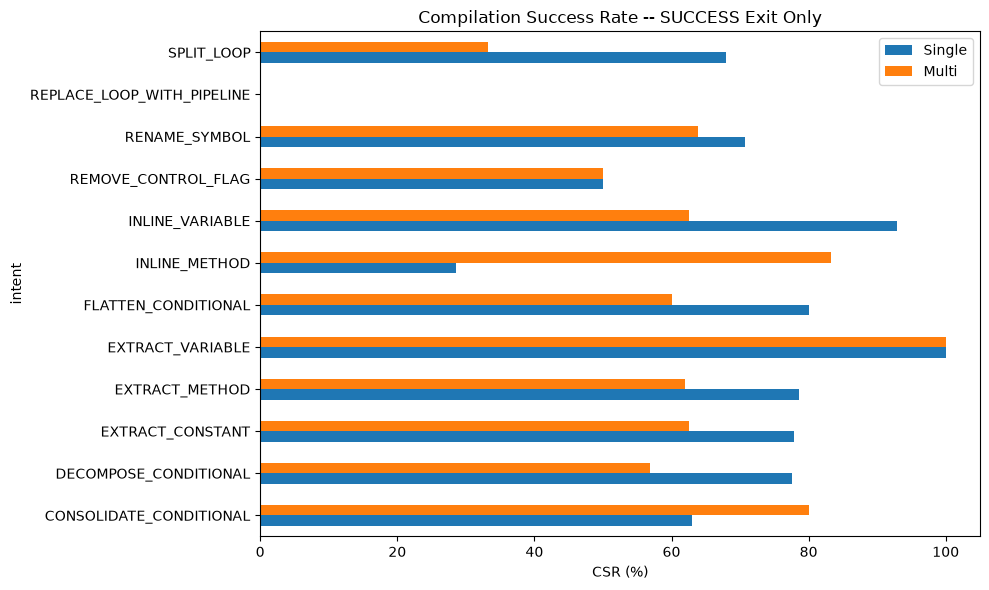

In [7]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
csr_succ=pd.DataFrame({'Single':intent_csr(s_valid),'Multi':intent_csr(m_valid)})
print(csr_succ)
ax=csr_succ.plot.barh(figsize=(10,6))
ax.set_title('Compilation Success Rate -- SUCCESS Exit Only')
ax.set_xlabel('CSR (%)'); plt.tight_layout(); plt.show()


#### CSR by Difficulty (SUCCESS Only)


            Single  Multi
difficulty               
Easy         74.63  61.11
Hard         63.46  55.00
Medium       64.05  55.77


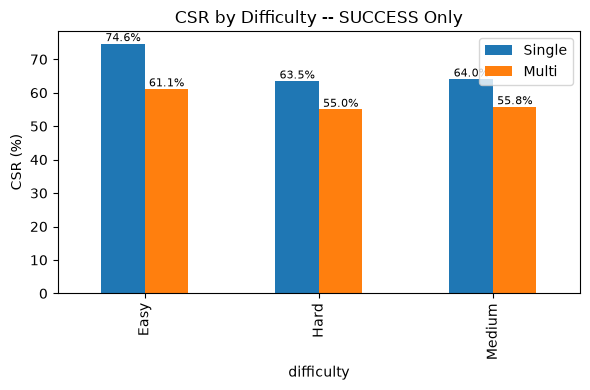

In [8]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
csr_diff_succ=pd.DataFrame({'Single':diff_csr(s_valid),'Multi':diff_csr(m_valid)}).round(2)
print(csr_diff_succ)
ax=csr_diff_succ.plot.bar(figsize=(6,4))
ax.set_title('CSR by Difficulty -- SUCCESS Only'); ax.set_ylabel('CSR (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
